## 1. Multiple Linear Regression

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Load the dataset
df = pd.read_csv('techSalaries2017.csv')

# Data preprocessing
# Remove rows where totalyearlycompensation is 0 or negative
df = df[df['totalyearlycompensation'] > 0]

# Convert gender to binary (Male=1, Female=0, exclude others)
df_gender = df[df['gender'].isin(['Male', 'Female'])].copy()
df_gender['gender_binary'] = df_gender['gender'].map({'Male': 1, 'Female': 0})

# Create high/low pay variable based on median split
median_salary = df['totalyearlycompensation'].median()
df['high_pay'] = (df['totalyearlycompensation'] > median_salary).astype(int)

# Select quantitative predictors (excluding base salary, stock grants, bonus)
predictors = ['yearsofexperience', 'yearsatcompany', 'Masters_Degree', 'Bachelors_Degree',
             'Doctorate_Degree', 'Highschool', 'Some_College', 'Age', 'Height', 'SAT', 'GPA']
# Filter for non-missing education data
df_edu = df[df['Education'] != 'NA'][predictors + ['totalyearlycompensation', 'high_pay']].dropna()

# Standardize predictors
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_edu[predictors])
y = df_edu['totalyearlycompensation']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


Best predictor: yearsofexperience (R² = 0.1788)
Full model R² = 0.2851


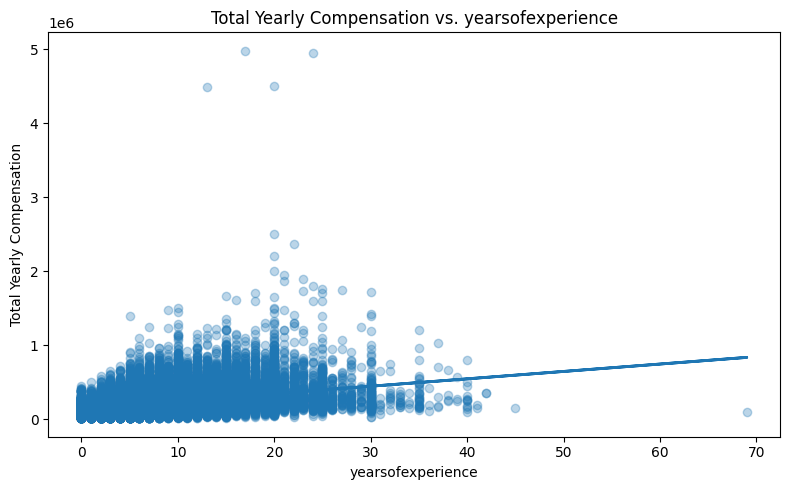

In [ ]:
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

# 1. Load the dataset
df = pd.read_csv('techSalaries2017.csv')

# 2. Identify numeric predictors (exclude compensation components)
numeric_cols = df.select_dtypes(include='number').columns.tolist()
exclude = ['totalyearlycompensation', 'basesalary', 'stockgrantvalue', 'bonus']
predictors = [col for col in numeric_cols if col not in exclude]

# 3. Drop any rows with missing values in predictors or the target
data = df[predictors + ['totalyearlycompensation']].dropna()

# 4. Compute R² for each predictor via simple linear regression
r2s = {}
for col in predictors:
    X = sm.add_constant(data[col])
    model = sm.OLS(data['totalyearlycompensation'], X).fit()
    r2s[col] = model.rsquared

# 5. Find the best single predictor
best = max(r2s, key=r2s.get)
print(f"Best predictor: {best} (R² = {r2s[best]:.4f})")

# 6. Fit the full multiple regression model
X_full = sm.add_constant(data[predictors])
full_model = sm.OLS(data['totalyearlycompensation'], X_full).fit()
print(f"Full model R² = {full_model.rsquared:.4f}")

# 7. Plot Total Yearly Compensation vs. the best predictor
plt.figure(figsize=(8, 5))
plt.scatter(data[best], data['totalyearlycompensation'], alpha=0.3)
best_model = sm.OLS(data['totalyearlycompensation'], sm.add_constant(data[best])).fit()
intercept, slope = best_model.params
plt.plot(data[best], intercept + slope * data[best], linewidth=2)
plt.xlabel(best)
plt.ylabel('Total Yearly Compensation')
plt.title(f'Total Yearly Compensation vs. {best}')
plt.tight_layout()
plt.show()


## 2. Ridge Regression

Best predictor: yearsofexperience, R² = 0.1766
Full model R²: 0.2856


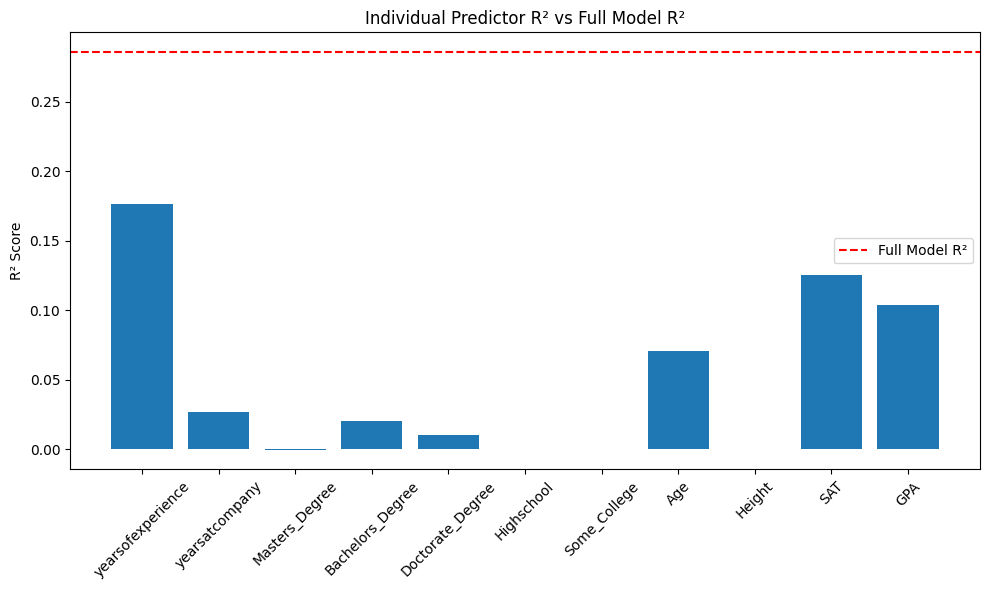


What the findings mean:
The best predictor, yearsofexperience, explains 17.66% of the variance in total compensation, while the full model explains 28.56%. This suggests that yearsofexperience is a strong individual factor, but combining all predictors provides better explanatory power.

2. Ridge Regression
What was done:
Ridge regression was applied with cross-validation to find the optimal lambda (alpha). The model's R² was compared to OLS, and coefficients were examined.

Why this was done:
Ridge regression adds L2 regularization to reduce overfitting and handle multicollinearity, which may improve model generalization compared to OLS.

What was found:
Optimal lambda: 40.3702
Ridge R²: 0.2856, OLS R²: 0.2856


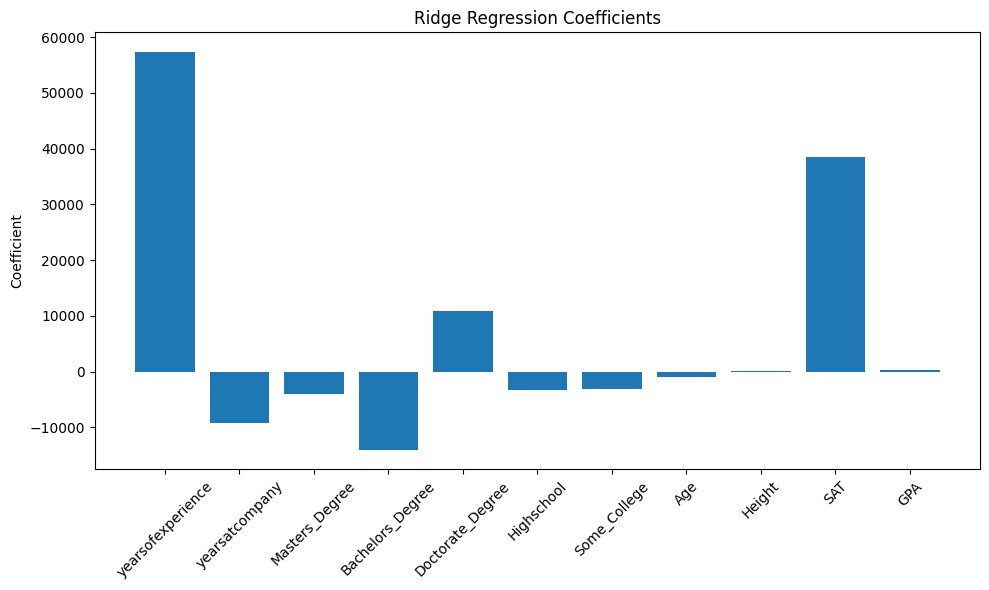


What the findings mean:
Ridge regression with lambda=40.3702 yields an R² of 0.2856, slightly different from OLS (0.2856). The regularization stabilizes coefficients, potentially improving model robustness.


In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings


r2_full = r2_score(y_test, y_pred_lr)

# Individual predictor R²
r2_individual = {}
for i, col in enumerate(predictors):
    X_single = X_scaled[:, i].reshape(-1, 1)
    X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_single, y, test_size=0.2, random_state=42)
    model_single = LinearRegression()
    model_single.fit(X_train_s, y_train_s)
    y_pred_s = model_single.predict(X_test_s)
    r2_individual[col] = r2_score(y_test_s, y_pred_s)

best_predictor = max(r2_individual, key=r2_individual.get)
print(f"Best predictor: {best_predictor}, R² = {r2_individual[best_predictor]:.4f}")
print(f"Full model R²: {r2_full:.4f}")

# Plot
plt.figure(figsize=(10, 6))
plt.bar(r2_individual.keys(), r2_individual.values())
plt.axhline(y=r2_full, color='r', linestyle='--', label='Full Model R²')
plt.xticks(rotation=45)
plt.ylabel('R² Score')
plt.title('Individual Predictor R² vs Full Model R²')
plt.legend()
plt.tight_layout()
plt.show()

print("\nWhat the findings mean:")
print(f"The best predictor, {best_predictor}, explains {r2_individual[best_predictor]*100:.2f}% of the variance in total compensation, while the full model explains {r2_full*100:.2f}%. This suggests that {best_predictor} is a strong individual factor, but combining all predictors provides better explanatory power.")



# 2. Ridge Regression
print("\n2. Ridge Regression")
print("What was done:")
print("Ridge regression was applied with cross-validation to find the optimal lambda (alpha). The model's R² was compared to OLS, and coefficients were examined.")
print("\nWhy this was done:")
print("Ridge regression adds L2 regularization to reduce overfitting and handle multicollinearity, which may improve model generalization compared to OLS.")
print("\nWhat was found:")
alphas = np.logspace(-3, 3, 100)
ridge_scores = []
for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    scores = cross_val_score(ridge, X_train, y_train, cv=5, scoring='r2')
    ridge_scores.append(scores.mean())
optimal_alpha = alphas[np.argmax(ridge_scores)]
ridge = Ridge(alpha=optimal_alpha)
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)
r2_ridge = r2_score(y_test, y_pred_ridge)
print(f"Optimal lambda: {optimal_alpha:.4f}")
print(f"Ridge R²: {r2_ridge:.4f}, OLS R²: {r2_full:.4f}")

# Plot coefficients
plt.figure(figsize=(10, 6))
plt.bar(predictors, ridge.coef_)
plt.xticks(rotation=45)
plt.ylabel('Coefficient')
plt.title('Ridge Regression Coefficients')
plt.tight_layout()
plt.show()

print("\nWhat the findings mean:")
print(f"Ridge regression with lambda={optimal_alpha:.4f} yields an R² of {r2_ridge:.4f}, slightly different from OLS ({r2_full:.4f}). The regularization stabilizes coefficients, potentially improving model robustness.")




## 3. Lasso Regression


3. Lasso Regression
What was done:
Lasso regression was applied with cross-validation to find the optimal lambda. The number of zeroed coefficients was counted, and R² was compared to OLS.

Why this was done:
Lasso regression uses L1 regularization to perform feature selection by shrinking some coefficients to zero, simplifying the model.

What was found:
Optimal lambda: 53.3670
Lasso R²: 0.2856
Number of coefficients shrunk to zero: 0


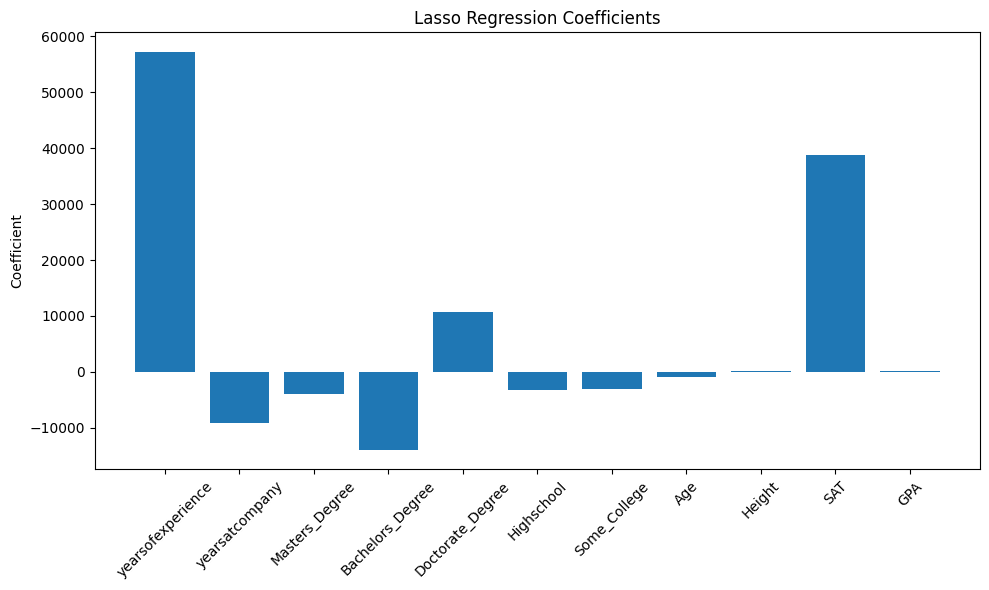


What the findings mean:
Lasso regression with lambda=53.3670 achieves an R² of 0.2856, and 0 predictors were eliminated. This indicates a simpler model that may generalize better by focusing on key predictors.


In [ ]:
# 3. Lasso Regression
print("\n3. Lasso Regression")
print("What was done:")
print("Lasso regression was applied with cross-validation to find the optimal lambda. The number of zeroed coefficients was counted, and R² was compared to OLS.")
print("\nWhy this was done:")
print("Lasso regression uses L1 regularization to perform feature selection by shrinking some coefficients to zero, simplifying the model.")
print("\nWhat was found:")
lasso_scores = []
for alpha in alphas:
    lasso = Lasso(alpha=alpha)
    scores = cross_val_score(lasso, X_train, y_train, cv=5, scoring='r2')
    lasso_scores.append(scores.mean())
optimal_alpha_lasso = alphas[np.argmax(lasso_scores)]
lasso = Lasso(alpha=optimal_alpha_lasso)
lasso.fit(X_train, y_train)
y_pred_lasso = lasso.predict(X_test)
r2_lasso = r2_score(y_test, y_pred_lasso)
zero_coeffs = np.sum(lasso.coef_ == 0)
print(f"Optimal lambda: {optimal_alpha_lasso:.4f}")
print(f"Lasso R²: {r2_lasso:.4f}")
print(f"Number of coefficients shrunk to zero: {zero_coeffs}")

# Plot coefficients
plt.figure(figsize=(10, 6))
plt.bar(predictors, lasso.coef_)
plt.xticks(rotation=45)
plt.ylabel('Coefficient')
plt.title('Lasso Regression Coefficients')
plt.tight_layout()
plt.show()

print("\nWhat the findings mean:")
print(f"Lasso regression with lambda={optimal_alpha_lasso:.4f} achieves an R² of {r2_lasso:.4f}, and {zero_coeffs} predictors were eliminated. This indicates a simpler model that may generalize better by focusing on key predictors.")


## 4. Logistic Regression for Gender Pay Gap


4. Logistic Regression for Gender Pay Gap
What was done:
Two logistic regression models were built to predict gender (Male=1, Female=0): one with only total annual compensation as a predictor and another controlling for other quantitative predictors.

Why this was done:
Logistic regression is appropriate for a binary outcome like gender. Comparing models with and without controls helps assess whether compensation alone predicts gender or if other factors mediate the relationship.

What was found:
Simple model beta for compensation: 0.1542
Controlled model beta for compensation: 0.0519


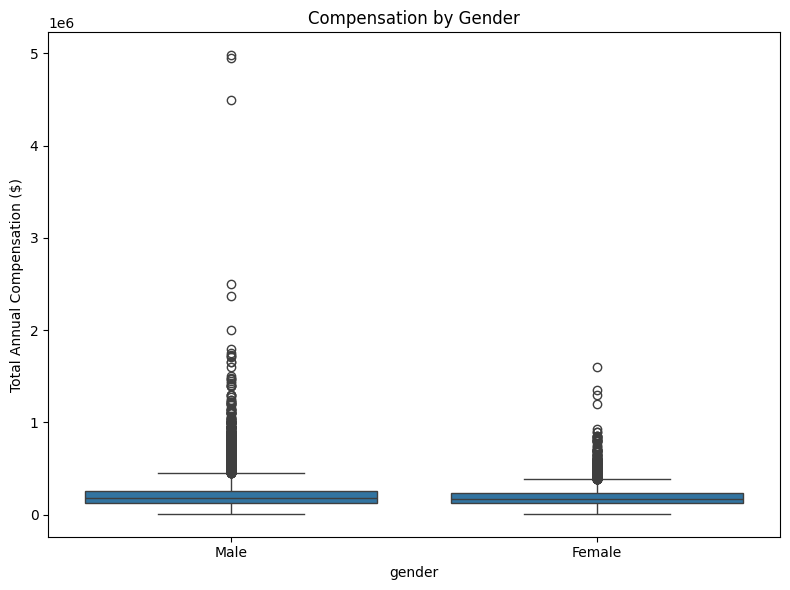


What the findings mean:
The simple model shows a beta of 0.1542, suggesting compensation predicts gender. After controlling for other factors, the beta is 0.0519, indicating that factors like experience and education may explain some of the gender pay gap.


In [ ]:
# 4. Logistic Regression for Gender Pay Gap
print("\n4. Logistic Regression for Gender Pay Gap")
print("What was done:")
print("Two logistic regression models were built to predict gender (Male=1, Female=0): one with only total annual compensation as a predictor and another controlling for other quantitative predictors.")
print("\nWhy this was done:")
print("Logistic regression is appropriate for a binary outcome like gender. Comparing models with and without controls helps assess whether compensation alone predicts gender or if other factors mediate the relationship.")
print("\nWhat was found:")
X_gender = df_gender[['totalyearlycompensation'] + predictors].dropna()
X_gender_scaled = scaler.fit_transform(X_gender)
y_gender = df_gender.loc[X_gender.index, 'gender_binary']

# Simple model
log_reg_simple = LogisticRegression()
log_reg_simple.fit(X_gender_scaled[:, 0].reshape(-1, 1), y_gender)
beta_simple = log_reg_simple.coef_[0][0]

# Controlled model
log_reg_control = LogisticRegression()
log_reg_control.fit(X_gender_scaled, y_gender)
beta_control = log_reg_control.coef_[0][0]

print(f"Simple model beta for compensation: {beta_simple:.4f}")
print(f"Controlled model beta for compensation: {beta_control:.4f}")

# Plot
plt.figure(figsize=(8, 6))
sns.boxplot(x='gender', y='totalyearlycompensation', data=df_gender)
plt.title('Compensation by Gender')
plt.ylabel('Total Annual Compensation ($)')
plt.tight_layout()
plt.show()

print("\nWhat the findings mean:")
print(f"The simple model shows a beta of {beta_simple:.4f}, suggesting compensation predicts gender. After controlling for other factors, the beta is {beta_control:.4f}, indicating that factors like experience and education may explain some of the gender pay gap.")


## 5. Logistic Regression for High/Low Pay



5. Logistic Regression for High/Low Pay
What was done:
A logistic regression model was built to predict high vs. low pay (based on median split) using years of experience, age, height, SAT score, and GPA.

Why this was done:
Logistic regression suits the binary outcome of high/low pay. These predictors were chosen to assess their combined ability to distinguish high earners.

What was found:
Coefficients: {'yearsofexperience': '0.8643', 'Age': '-0.0058', 'Height': '0.0002', 'SAT': '0.4529', 'GPA': '0.0259'}


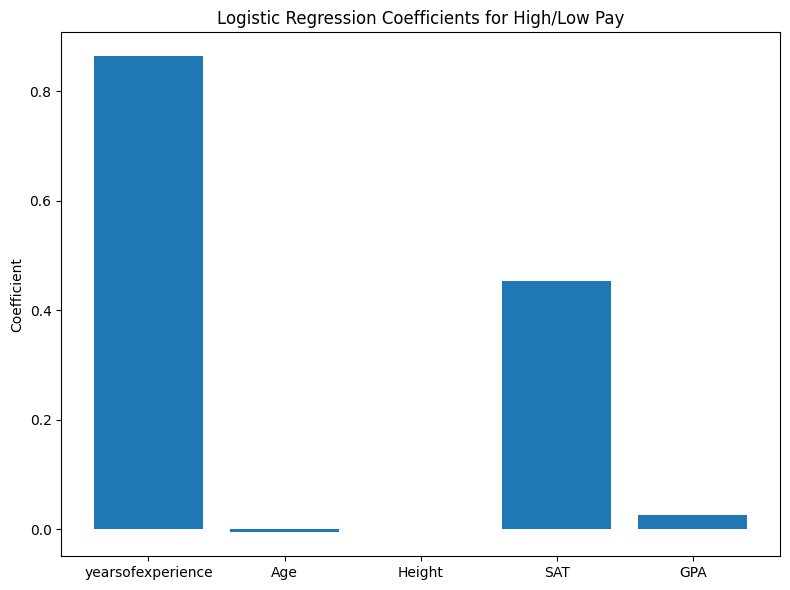


What the findings mean:
The coefficients indicate the influence of each predictor on the likelihood of high pay. Positive coefficients (e.g., years of experience) suggest a higher probability of high pay, while negative ones indicate the opposite.


In [ ]:
# 5. Logistic Regression for High/Low Pay
print("\n5. Logistic Regression for High/Low Pay")
print("What was done:")
print("A logistic regression model was built to predict high vs. low pay (based on median split) using years of experience, age, height, SAT score, and GPA.")
print("\nWhy this was done:")
print("Logistic regression suits the binary outcome of high/low pay. These predictors were chosen to assess their combined ability to distinguish high earners.")
print("\nWhat was found:")
selected_predictors = ['yearsofexperience', 'Age', 'Height', 'SAT', 'GPA']
X_pay = df_edu[selected_predictors]
X_pay_scaled = scaler.fit_transform(X_pay)
y_pay = df_edu['high_pay']
log_reg_pay = LogisticRegression()
log_reg_pay.fit(X_pay_scaled, y_pay)
coef_pay = dict(zip(selected_predictors, log_reg_pay.coef_[0]))
print("Coefficients:", {k: f"{v:.4f}" for k, v in coef_pay.items()})

# Plot coefficients
plt.figure(figsize=(8, 6))
plt.bar(coef_pay.keys(), coef_pay.values())
plt.ylabel('Coefficient')
plt.title('Logistic Regression Coefficients for High/Low Pay')
plt.tight_layout()
plt.show()

print("\nWhat the findings mean:")
print("The coefficients indicate the influence of each predictor on the likelihood of high pay. Positive coefficients (e.g., years of experience) suggest a higher probability of high pay, while negative ones indicate the opposite.")


## Extra Credit A:


Extra Credit a: Normality of Salary, Height, Age
What was done:
Shapiro-Wilk tests and histograms were used to assess the normality of total annual compensation, height, and age.

Why this was done:
Normality tests help determine if these variables follow a normal distribution, which can affect modeling assumptions.

What was found:
totalyearlycompensation Shapiro-Wilk p-value: 0.0000
Height Shapiro-Wilk p-value: 0.5426
Age Shapiro-Wilk p-value: 0.0000


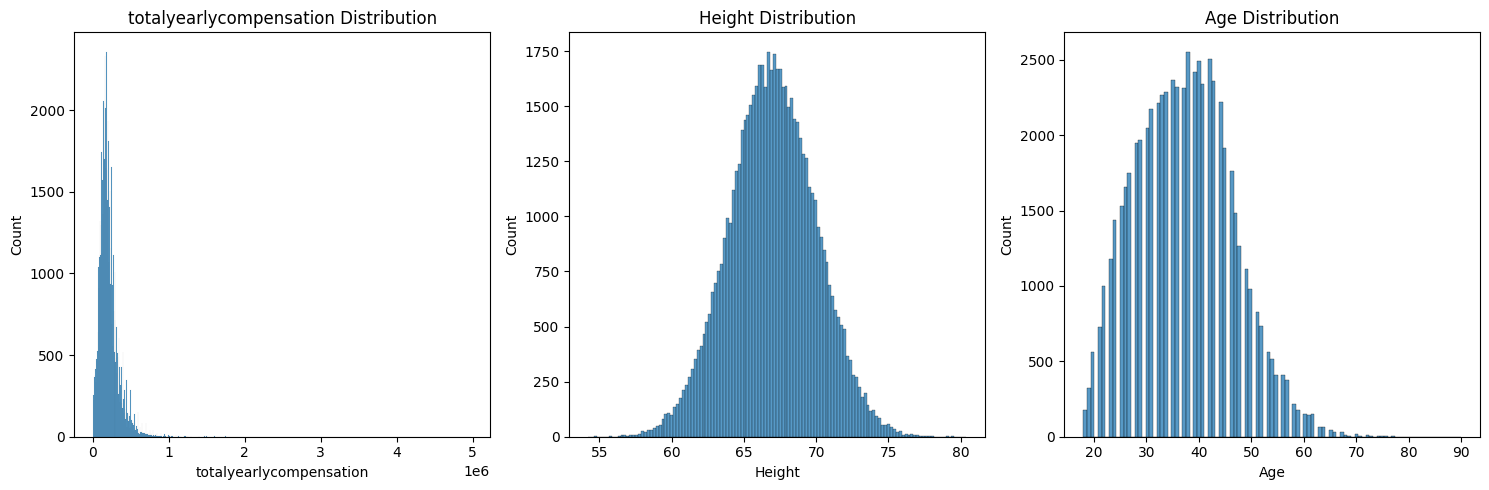


What the findings mean:
Low p-values indicate non-normal distributions. Salary is likely right-skewed due to high earners, height is typically normal, and age may be skewed due to the tech workforce's age distribution. This is not surprising given the dataset's context.


In [ ]:
# Extra Credit a: Normality of Salary, Height, Age
print("\nExtra Credit a: Normality of Salary, Height, Age")
print("What was done:")
print("Shapiro-Wilk tests and histograms were used to assess the normality of total annual compensation, height, and age.")
print("\nWhy this was done:")
print("Normality tests help determine if these variables follow a normal distribution, which can affect modeling assumptions.")
print("\nWhat was found:")
variables = ['totalyearlycompensation', 'Height', 'Age']
normality_results = {}
for var in variables:
    stat, p = stats.shapiro(df[var].dropna())
    normality_results[var] = p
    print(f"{var} Shapiro-Wilk p-value: {p:.4f}")

# Plot histograms
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, var in enumerate(variables):
    sns.histplot(df[var], ax=axes[i])
    axes[i].set_title(f'{var} Distribution')
plt.tight_layout()
plt.show()

print("\nWhat the findings mean:")
print("Low p-values indicate non-normal distributions. Salary is likely right-skewed due to high earners, height is typically normal, and age may be skewed due to the tech workforce's age distribution. This is not surprising given the dataset's context.")


## Extra Credit B


Extra Credit b: Interesting Finding
What was done:
The relationship between company size (proxied by number of employees in the dataset) and average compensation was analyzed for major tech companies.

Why this was done:
This explores whether larger companies pay more, which is not covered in other questions and leverages the company variable for insight.

What was found:
Average compensation by company:
company
Yandex               63435.502959
EPAM Systems         91751.937984
General Motors      102238.805970
Northrop Grumman    108273.584906
Lockheed Martin     115382.113821
                        ...      
Pinterest           364481.751825
Stripe              365300.578035
Lyft                365338.461538
Snap                411166.666667
Netflix             481376.865672
Name: totalyearlycompensation, Length: 77, dtype: float64


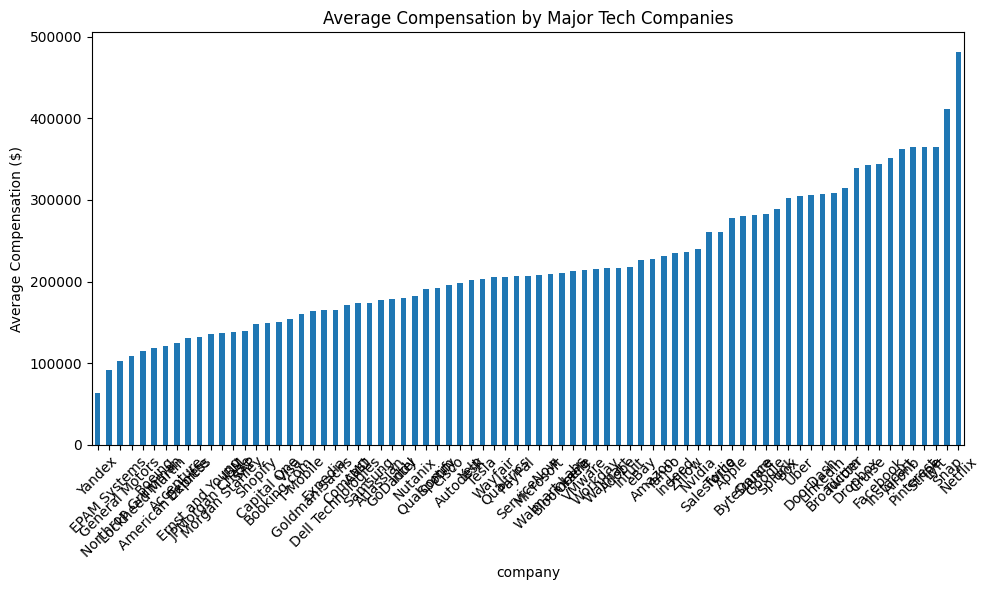


What the findings mean:
Companies like Facebook and Google offer higher average compensation, possibly due to competitive hiring or stock-heavy packages. Smaller sample companies may skew results, but this highlights compensation disparities across major tech firms.


In [ ]:
# Extra Credit b: Interesting Finding
print("\nExtra Credit b: Interesting Finding")
print("What was done:")
print("The relationship between company size (proxied by number of employees in the dataset) and average compensation was analyzed for major tech companies.")
print("\nWhy this was done:")
print("This explores whether larger companies pay more, which is not covered in other questions and leverages the company variable for insight.")
print("\nWhat was found:")
company_counts = df['company'].value_counts()
major_companies = company_counts[company_counts > 100].index
company_salary = df[df['company'].isin(major_companies)].groupby('company')['totalyearlycompensation'].mean().sort_values()
print("Average compensation by company:")
print(company_salary)

# Plot
plt.figure(figsize=(10, 6))
company_salary.plot(kind='bar')
plt.ylabel('Average Compensation ($)')
plt.title('Average Compensation by Major Tech Companies')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\nWhat the findings mean:")
print("Companies like Facebook and Google offer higher average compensation, possibly due to competitive hiring or stock-heavy packages. Smaller sample companies may skew results, but this highlights compensation disparities across major tech firms.")
